# Causal Discovery: Learning Causal Structure from Data

This notebook teaches causal discovery through interactive visualizations and
incremental examples, building intuition about how algorithms infer causal
structure from observational data.

In [5]:
%load_ext autoreload
%autoreload 2

import logging

try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore

In [8]:
import helpers.hmodule as hmodule

hmodule.install_module_if_not_present(
    ["networkx"],
    use_activate=True,
    use_sudo=False,
    venv_path="/opt/venv",
)

Module 'networkx' is already installed.


In [9]:
import helpers.hnotebook as hnotebo

import msml610_utils as ut
import L10_2_causal_discovery_utils as utils

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)
hnotebo.set_logger_to_print(_LOG)
hnotebo.set_all_loggers_to_print()

Setting notebook style
Notebook signature
Python 3.12.13
Linux b8b39f29e228 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 GNU/Linux
numpy version=2.4.5
matplotlib version=3.10.9


# Cell 1: The Core Problem: Correlation vs. Causation

**Goal**:
- Recognize that identical observational patterns can hide opposite causal implications

**Plots**:
- Two scatter plots side-by-side showing identical correlation patterns
- Both show X and Y with strong correlation (r = 0.8 to 0.99)
- Left plot labeled: "Chain: X → Y" with annotation "(if we intervene on X, Y changes)"
- Right plot labeled: "Reverse: Z → Y → X" with annotation "(intervening on X has no effect)"
- Summary annotations showing decision scenarios

**Parameters**:
- `Correlation (r)`: Strength of correlation between variables (0.3 to 0.99)
- `Mode`: Toggle between observational vs. interventional reasoning

**Key observations**:
- Prediction and causation require fundamentally different reasoning
- Correlation alone cannot determine causal direction
- Same correlation pattern can hide opposite causal implications
    - This is the core problem: no amount of observational data alone distinguishes these structures
    - We need additional assumptions or interventions

In [10]:
# Display interactive widget for correlation vs causation.
utils.cell1_correlation_vs_causation()

# Cell 2: Markov Equivalence: Three Indistinguishable Structures

**Goal**:
- Show that different DAGs encode identical conditional independencies
- Introduce the CPDAG as the best we can do with observational data alone
- Understand why causal discovery outputs equivalence classes, not unique DAGs

**Plots**:
- Three DAGs side-by-side: Chain (X → Y → Z), Reverse (Z → Y → X), Common Cause (X ← Y → Z)
- Below each DAG: list of implied conditional independencies
  - All three imply: X ⊥ Z | Y (X independent of Z given Y)
  - Distributions are mathematically identical
- Visual summary: CPDAG showing equivalence class with skeleton and ambiguous edge marks
- Histograms showing correlation patterns:
  - Marginal correlation X-Z: identical across all three structures
  - Conditional correlation X-Z|Y: near-zero for all

**Parameters**:
- `Sample Size (N)`: Number of observations (50 to 5000)
  - Larger samples provide stronger statistical power for CI tests
  - But even infinite samples cannot distinguish Markov equivalent structures

**Key observations**:
- Observational data recover only conditional independence structure
- Edge directions in chains are fundamentally ambiguous
- CPDAG is the most informative output possible from observational data alone
- All three structures satisfy the same independencies and have identical covariance matrices

In [11]:
# Display Markov equivalence interactive widget.
utils.cell2_markov_equivalence()

# Cell 3: Why Direction Matters: Causal Effects via Intervention

**Goal**:
- Show concretely why edge direction determines causal effect
- Build intuition for why structure recovery is crucial for policy
- Demonstrate that same correlation leads to wildly different intervention outcomes

**Plots**:
- Three side-by-side panels showing counterfactual outcomes for each structure
- Scenario: intervene on X (set to high value) and observe effect on Z
  - Chain (X → Y → Z): large effect on Z (green bar)
  - Reverse (Z → Y → X): no effect on Z (red bar)
  - Common Cause (Y confounds both): no direct effect on Z (orange bar)
- Bar chart showing effect sizes with confidence bands
- Visualization of how effect propagates (or not) through the DAG

**Parameters**:
- `Intervention Strength`: Magnitude of change to X (0 to 3)
- `Sample Size (N)`: Observations used for effect estimation (100 to 5000)

**Key observations**:
- Same observational correlation, wildly different causal effects
- Edge direction determines whether an intervention is effective
- Policy decisions depend critically on DAG structure
- Choosing the wrong DAG leads to ineffective or harmful interventions

In [12]:
# Display intervention effects interactive widget.
utils.cell3_causal_effects()

# Cell 4: The PC Algorithm: Learning From Conditional Independence Tests

**Goal**:
- Understand constraint-based discovery
- See step-by-step how PC uses conditional independence (CI) tests
- Build intuition for why CI tests are powerful but fallible

**Plots**:
- Animated visualization of PC algorithm on 4-5 variable DAG
- Left panel: evolving graph structure
  - Start with fully connected graph
  - Step-by-step edge removal as CI tests pass
  - Highlight separating sets
- Right panel: current test details
  - Test number and description
  - p-value and threshold comparison
  - Separating set information

**Parameters**:
- `Alpha (CI threshold)`: Significance level for CI tests (0.001 to 0.2)
  - Lower alpha: stricter tests, keep more edges
  - Higher alpha: liberal tests, remove more edges
- `Test Type`: CI test method (Partial correlation, Gaussian G-squared, Conditional MI)
- `Speed`: Animation speed for step-by-step progression

**Key observations**:
- PC recovers skeleton via CI tests, then orients v-structures (colliders)
- Stronger distributional assumptions enable more powerful tests
- CI test errors propagate directly to DAG structure errors
- PC is sound in the large-sample limit, but CI tests are underpowered in finite samples

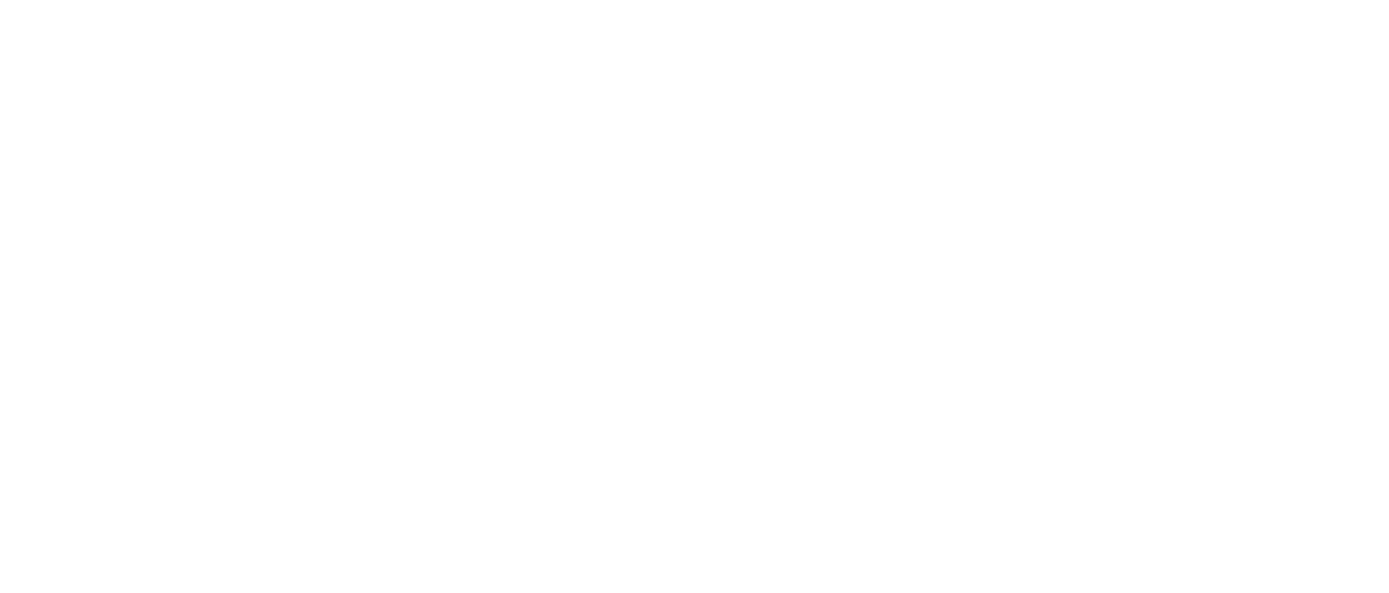

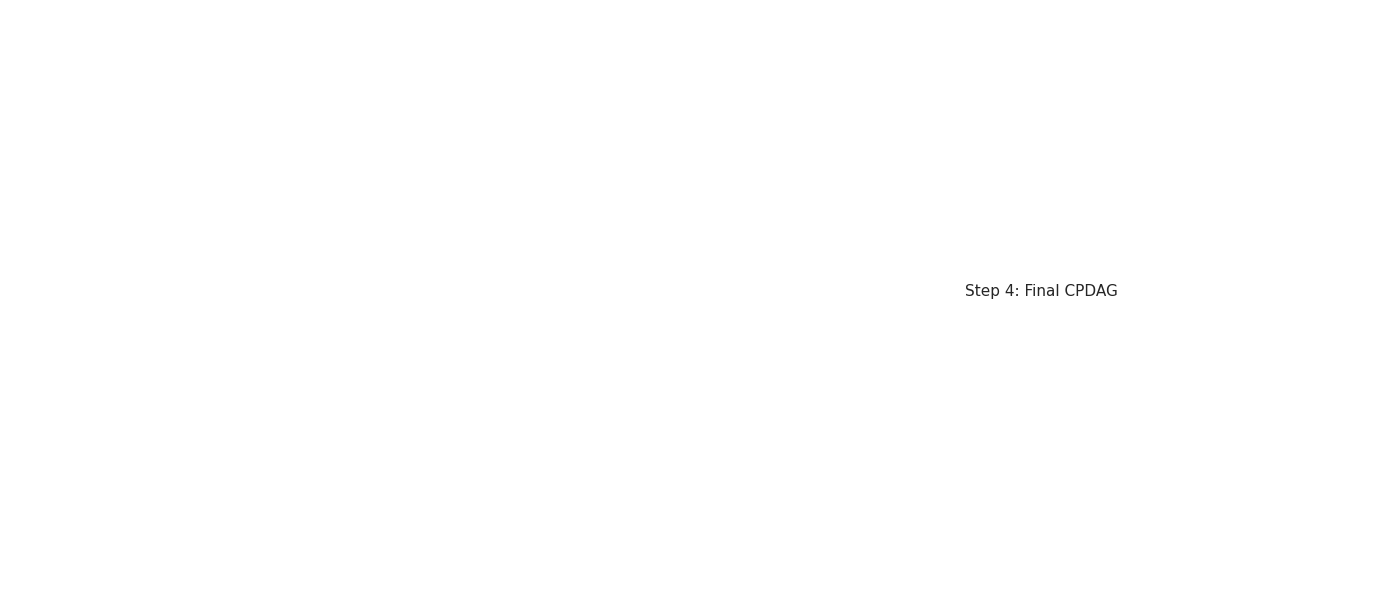

PC Algorithm: Sound in large sample limit, but CI tests are underpowered in finite samples.


In [14]:
# Display PC algorithm interactive widget.
utils.cell4_pc_algorithm()

# Cell 5: Score-Based Search: GES (Greedy Equivalence Search)

**Goal**:
- Introduce score-based discovery where algorithms optimize fit to data
- Show how BIC balances likelihood fit with model complexity
- Understand forward-backward search strategy

**Plots**:
- Left panel: animated DAG evolving during search
  - Starts empty (no edges)
  - Shows which edge is being added/removed at each step
  - Color-codes edges by score contribution (bright = high improvement)
  - Current BIC score displayed below graph
- Right panel: line plot of BIC score vs. iteration
  - Annotations for forward/backward phase transitions
  - Shows local maxima and convergence plateau

**Parameters**:
- `Sample Size (N)`: Number of observations (50 to 10000)
  - BIC penalty proportional to log(N) for model complexity
  - Larger N allows more edges
- `Regularization`: Strength of sparsity penalty (0 to 2)
  - Higher regularization: fewer edges

**Key observations**:
- GES searches DAG space using greedy forward-backward heuristics
- BIC balances likelihood fit with model complexity
- Forward phase adds edges, backward removes low-value edges
- GES is guaranteed to recover the equivalence class in the limit
- Greedy search can get stuck in local optima; multiple random starts improve robustness

In [ ]:
# Display GES interactive widget.
utils.cell5_ges_algorithm()

# Cell 6: Non-Gaussian Methods: LiNGAM for Full Identifiability

**Goal**:
- Show how non-Gaussianity breaks directional symmetry
- Enable full DAG recovery instead of just equivalence classes
- Build intuition for when functional assumptions are powerful

**Plots**:
- Three scatter plots showing data clouds for X→Y relationships
  - Gaussian case: symmetric elliptical shapes (same covariance for both directions)
  - Non-Gaussian case: asymmetric shapes revealing causal direction
- Adjacency matrices showing recovered structure:
  - Matrix B where Xi = sum(bij * Xj) + ei
  - B is acyclic (uniquely oriented DAG)
- Histograms of noise distributions
  - Show non-Gaussianity metrics (heavy tails, skewness)
  - Highlight that ICA recovers independent non-Gaussian components

**Parameters**:
- `Skewness`: Non-Gaussianity of noise distribution (0 = Gaussian to 5 = heavy-tailed)
  - Gaussian: chains indistinguishable
  - Skewed: asymmetry reveals direction
- `Signal-to-Noise Ratio`: Ratio of signal to noise strength (0.1 to 0.99)

**Key observations**:
- Gaussian linear models are symmetric: X→Y and Y→X produce same distribution
- Non-Gaussianity breaks symmetry: LiNGAM exploits asymmetry to orient edges
- LiNGAM provides full DAG identification under linear non-Gaussian assumptions
- Jarque-Bera test can detect non-Gaussianity in data

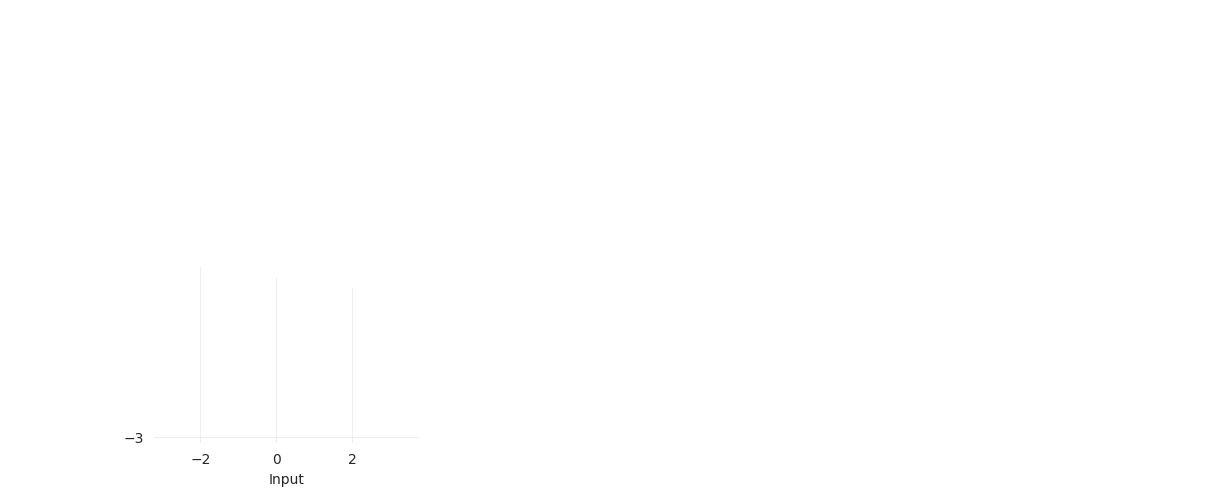


Jarque-Bera Test: statistic=0.5850, p-value=0.7464
Result: Data appear GAUSSIAN (cannot reject normality)


In [15]:
# Display LiNGAM non-Gaussian interactive widget.
utils.cell6_lingam_nongaussian()

# Cell 7: Comparing Algorithms: Which One to Use?

**Goal**:
- Show outputs from PC, GES, and LiNGAM on the same data
- Build intuition for algorithm selection based on assumptions
- Understand consensus edges as most trustworthy

**Plots**:
- Three DAG outputs side-by-side
  - PC output: CPDAG with mixed directed/undirected edges
  - GES output: Full DAG with directed edges
  - LiNGAM output: Full DAG with edge weight labels
- Below each: summary statistics
  - Edge count, ambiguity count, computation time
  - Edge weights or confidence scores
- Consensus visualization: which edges recovered by each algorithm

**Parameters**:
- `Dataset Type`: Nature of data (Linear Gaussian, Linear Non-Gaussian, Nonlinear)
- `Sample Size (N)`: Number of observations (100 to 5000)
- Toggle: show edge weights/confidence scores

**Key observations**:
- PC: constraint-based, good for small samples, returns equivalence class
- GES: score-based, more directed edges, assumes no hidden confounders
- LiNGAM: functional approach, requires non-Gaussianity, full DAG recovery
- Consensus edges (found by multiple algorithms) are most trustworthy
- Algorithm choice depends on data type, sample size, and assumptions

In [ ]:
# Display algorithm comparison interactive widget.
utils.cell7_algorithm_comparison()

# Cell 8: Validating Discovered DAGs with Refutation Tests

**Goal**:
- Show how to validate that a discovered DAG's implications hold in the data
- Understand refutation as check on model assumptions
- Build sensitivity to hidden confounding

**Plots**:
- Left panel: discovered CPDAG from PC or GES
- Right panel: validation dashboard with three sections
  - CI test validation: bar chart of p-values for all implied independencies
    - Green bars: CI holds (p > alpha)
    - Red bars: CI violated (p <= alpha)
  - Placebo test: discovery output when applied to shuffled data
    - Should find nothing or very few edges
  - Sensitivity analysis: line plot showing conclusion robustness vs. hidden confounder strength

**Parameters**:
- `Alpha (CI threshold)`: Significance level for validation (0.01 to 0.2)
- `Confounder Strength`: Magnitude of hidden confounding (0 to 1)

**Key observations**:
- Validation checks whether discovered DAG implications hold in data
- Low validation score suggests violated assumptions (hidden confounders, non-stationarity)
- Placebo tests detect spurious structure discovery in noise
- Sensitivity analysis quantifies robustness to unobserved confounders
- A discovered DAG is a hypothesis; validation checks consistency with data

In [ ]:
# Display validation interactive widget.
utils.cell8_validation()

# Cell 9: Domain Knowledge Integration: Constraints and Prior DAGs

**Goal**:
- Show how expert knowledge (forbidden/required edges, temporal order)
- Drastically improves discovery accuracy without losing data-driven insights
- Understand constraint-based discovery as combining human and machine intelligence

**Plots**:
- Top left: fully automatic discovery result (no constraints)
- Top right: expert-specified constraints listed
  - Forbidden edges (e.g., "outcome cannot cause treatment")
  - Required edges (e.g., "treatment causes outcome")
  - Temporal tiers showing variable layers
- Bottom left: discovery with constraints applied
  - Reduced edge candidate space
  - Fewer ambiguities in final DAG
- Bottom right: impact summary
  - Search space reduction percentage
  - Edges affected by constraints

**Parameters**:
- `Prior Strength`: How much to trust expert knowledge (0 to 1)

**Key observations**:
- Partial domain knowledge drastically reduces search space and improves accuracy
- Constraints must be correct: wrong priors inject errors
- Temporal ordering is the strongest constraint
- Expert and automated discovery are complementary
- Combine automatic discovery with domain expertise for best results

In [16]:
# Display domain knowledge integration interactive widget.
utils.cell9_domain_knowledge()

# Cell 10: End-to-End Workflow: From Data to Validated DAG

**Goal**:
- Integrate all techniques into a complete discovery pipeline
- Show the practical workflow from raw data to validated causal structure
- Understand causal discovery as an iterative, multi-stage process

**Plots**:
- Multi-panel workflow visualization with six stages:
  1. Data preparation: variable histograms, non-Gaussianity test results, temporal order
  2. Algorithm selection and execution: run selected algorithms with results
  3. Consensus step: Venn diagram of edges found by each algorithm
  4. Refinement step: expert review with constraint options
  5. Validation step: refutation tests with pass/fail results
  6. Final DAG: refined and validated causal structure
- Progress bar showing current workflow stage
- Summary statistics at each stage

**Parameters**:
- `Dataset`: Type of data (Synthetic: Linear Gaussian, Linear Non-Gaussian, Nonlinear; Real: economic, health)
- `Algorithms`: Select which algorithms to run (PC, GES, LiNGAM checkboxes)
- `Progress Stage`: Current stage in the workflow (0 to 5)

**Key observations**:
- Discovery is a pipeline, not a single algorithm call
- Multiple algorithms provide robustness via consensus
- Expert review and constraints improve accuracy without losing data-driven insights
- Validation ensures the discovered structure is plausible
- Causal discovery is most powerful when combined with domain knowledge and careful interpretation

In [ ]:
# Display end-to-end workflow interactive widget.
utils.cell10_end_to_end_workflow()

# Summary

Causal discovery is a powerful tool for inferring causal structure from observational data,
but it requires careful attention to:

- **Assumptions**: Different algorithms make different assumptions about the data
- **Identifiability**: Some structures are inherently unidentifiable from observational data
- **Validation**: Discovered DAGs must be validated and sensitivity-tested
- **Domain Knowledge**: Expert knowledge dramatically improves results
- **Interpretation**: Discovered structures are hypotheses for investigation, not definitive proofs

The workflow balance automated discovery with expert judgment, validated with refutation tests,
and interpreted as a hypothesis for investigation.